# Single-qubit $X(\pi/2)$: Gaussian vs. Gaussian+DRAG vs. Optimized

The $X(\pi)$ study repeated at half the rotation angle. Same device, same gate time
$T=50$ ns, same $M=20$ basis, same budget weights — **only $\theta$ changes**, and with it
the fluence floor $F_0=\theta^2/T$ the validity guard is quoted against.

Why this is not just a rescaling: a $\pi/2$ Gaussian carries half the area, so its peak sits
near $24\%$ of $\Omega_{\max}$ instead of $48\%$. The peak epigraph is nowhere near active,
and the optimizer has roughly twice the amplitude headroom it had for $X(\pi)$ — the same
direction that drove arm C out of the surrogate's domain of validity. Which guard binds,
and whether the surrogate stays honest, is the question this notebook answers.

Everything below is gate-generic and comes from `proposals/_gatelib`; this folder only
binds the target gate (`armlib.py` -> `gatespec.SPECS["Xpi2"]`).
The companion folder `1qb_Gaussian-drag-optimization` holds the reference $X(\pi)$ study
this one mirrors — read its `README.md` first for the method, the evaluation-object rule
and the calibration protocol, which are unchanged here.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, str(Path.cwd()))
import armlib as al

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.facecolor": "white"})

DEV = al.DEV
print(f"target gate = {al.GATE.name}   theta = {al.THETA:.6f} rad   "
      f"axis azimuth = {al.GATE.phi_axis:.6f} rad   solve_mode = {al.GATE.solve_mode}")
print(f"T           = {al.T:g} ns          M = {DEV.n_modes}")
print(f"Delta       = {DEV.delta:.6f} rad/ns   ({DEV.anharmonicity*1e3:+.0f} MHz)")
print(f"Omega_max   = {DEV.rabi_max_rate:.6f} rad/ns    eta = Omega_max/|Delta| = {DEV.eta:.3f}")
print(f"design eps  = {DEV.control_error:.1%}      design delta_z = {DEV.static_detuning*1e3:.1f} MHz rms")
print(f"decoh floor = {DEV.decoherence_floor:.4e}   (waveform independent, same for every arm)")
print(f"AWG export  = {al.N_EXPORT} samples @ {DEV.sample_rate} GS/s")
print(f"fluence unit F0 = theta^2/T = {al.FLUENCE_FLOOR:.5f} rad^2/ns")
print(f"arms available  = {al.ARM_ORDER}")

target gate = X(pi/2)   theta = 1.570796 rad   axis azimuth = 0.000000 rad   solve_mode = independent
T           = 50 ns          M = 20
Delta       = -1.256637 rad/ns   (-200 MHz)
Omega_max   = 0.314159 rad/ns    eta = Omega_max/|Delta| = 0.250
design eps  = 2.0%      design delta_z = 0.1 MHz rms
decoh floor = 4.1667e-04   (waveform independent, same for every arm)
AWG export  = 120 samples @ 2.4 GS/s
fluence unit F0 = theta^2/T = 0.04935 rad^2/ns
arms available  = ('A', 'B')


## 1. The arms

| Arm | Layer | Construction |
|---|---|---|
| **A** Gaussian | `planar` | truncated Gaussian $\sigma=T/6$, area $=\theta$, fitted to $M=20$ sine modes, `c1`-projected, $\Omega_y\equiv0$ |
| **B** Gaussian+DRAG | `planar_drag` | same $\kappa$, DRAG/Stark readout supplies $\Omega_y$ — the industry baseline |
| **C** Optimized | `general` | `solve_budget`, warm started from B, no fluence cap (F06-min recipe) |
| **D** Opt + fluence cap | `general` | C plus $\int\kappa^2dt\le 2F_0$ (F06b recipe) |
| **E** Opt AD-exact | `general` | `objective_mode="ad_exact"`, cap $4F_0$ (F06e recipe) |

C/D/E appear only once their runs exist. Produce them with
`python run_construction.py C` (then `D`, then `E`) and register each `run_id` in
`_gatelib/gatespec.py`.

In [2]:
arms = al.build_arms()
ARM_ORDER = al.ARM_ORDER
for k in ARM_ORDER:
    a = arms[k]
    print(f"{k}  {a.name:18s} layer={a.layer:12s} ||a||={np.linalg.norm(a.a):.4f} "
          f"||c||={np.linalg.norm(a.c):.4e} Phi_0={a.Phi_0:+.4f} run_id={getattr(a, 'run_id', None)}")
    print(f"     {a.note}")

missing = [k for k in ("C", "D", "E") if k not in arms]
if missing:
    print(f"\nnot solved yet: {missing}. Everything below runs on the available arms; "
          f"re-run this notebook after registering the new run_ids in _gatelib/gatespec.py.")

A  Gaussian           layer=planar       ||a||=0.0581 ||c||=0.0000e+00 Phi_0=+0.0000 run_id=None
     Truncated Gaussian (sigma=T/6) fitted to M=20 sine modes, c1-projected and rescaled to theta=1.570796. Omega_y == 0: no DRAG, no Stark correction.
B  Gaussian + DRAG    layer=planar_drag  ||a||=0.0581 ||c||=0.0000e+00 Phi_0=+0.0000 run_id=None
     Truncated Gaussian (sigma=T/6) for theta=1.570796, least-squares fit to M=20 sine modes (relRMS after c1 projection = 8.72e-03), DRAG/Stark readout. The industry baseline.

not solved yet: ['C', 'D', 'E']. Everything below runs on the available arms; re-run this notebook after registering the new run_ids in _gatelib/gatespec.py.


### Solving the optimized arms in place (optional)

`arms` above holds whichever arms already have a recorded run. To produce a missing one
without leaving the notebook, list it in `SOLVE` below: `al.solve_arm` takes the
Gaussian+DRAG arm (or the previous optimized arm) as its warm start and runs
`solve_budget` right here.

Two things it does **not** shortcut, on purpose:

* **It still records to `_runs/<run_id>/`.** A solve that lives only in kernel memory
  cannot be plotted from a RunRecord, re-checked on a finer grid, or quoted — the
  project requires every optimization on disk. Recording also means you only pay for it
  once: register the printed `run_id` in `_gatelib/gatespec.py` and every later
  re-execution loads it instead of re-solving.
* **The recipe is `ARM_RECIPES`'s, not a local one.** Same definition
  `run_construction.py` uses, so a notebook solve and a script solve are the same run.

Arm D goes to `maxiter=20000` and is the one worth running from the shell instead —
a kernel holding it for that long is a liability, and `run_construction.py D` is
exactly this call. Chaining in one session works: `E` warm-starts from `D`, and passing
the in-memory arm skips the register-and-restart round trip.

In [ ]:
SOLVE = []          # e.g. ["C"], or ["C", "D", "E"] to chain the whole lineage
DRY_RUN = False     # True: build each problem and print its manifest, solve nothing

for key in SOLVE:
    warm = arms.get(al.ARM_RECIPES[key].warm)  # in-memory warm start if we just solved it
    arm, result = al.solve_arm(key, warm_arm=warm, dry_run=DRY_RUN)
    if arm is not None:
        arms[key] = arm
        print()

ARM_ORDER = tuple(k for k in ("A", "B") + al.OPTIMIZED_ARMS if k in arms)
print("ARM_ORDER =", ARM_ORDER)
if SOLVE and not DRY_RUN:
    print("Solved run_id(s) are auto-registered in configs/runs.json; a fresh kernel picks "
          "them up without re-solving.")

## Fig. 1 — the control waveforms

Top row: the **played** waveform of each arm at the AWG sampling — what the instrument
would actually emit — with $\pm\Omega_{\max}$ as a dashed ceiling. Arm A's
$\Omega_y\equiv0$ is drawn so B's DRAG quadrature is legible as a difference.

Bottom row: the **design curve** — curvature $\kappa(t)$ (identical for A and B by
construction) and torsion $\tau(t)$ with the R-guard bound drawn in.

★ Watch the printed peak utilisation. It is the headroom the optimizer has, and it is
the one number that changes most between rotation angles.

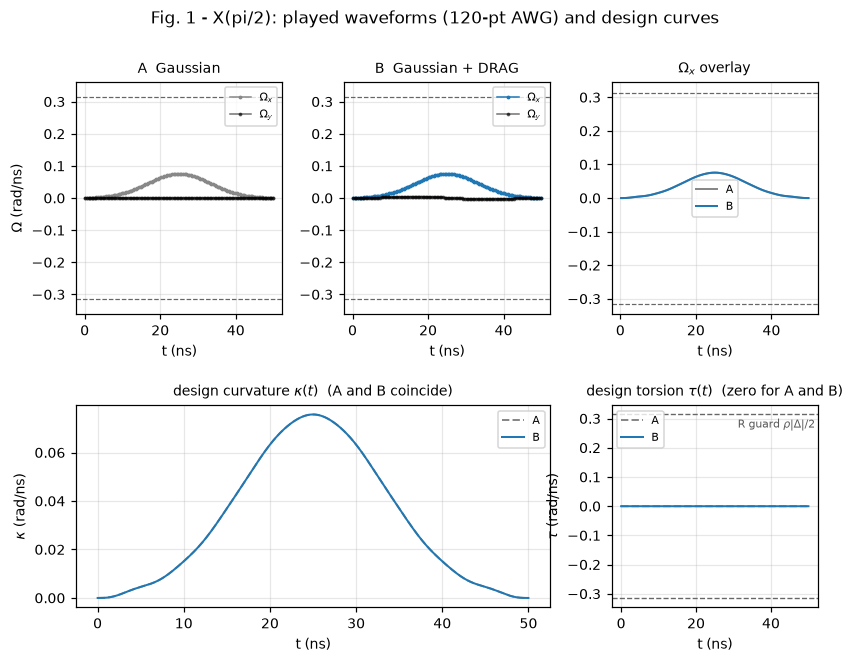

peak utilisation (played |Omega| / Omega_max):
  A:  24.1%
  B:  24.1%


In [3]:
from curve_opt import geometry

t_awg, _ = geometry.midpoint_grid(al.T, al.N_EXPORT)
t_fine, _ = geometry.midpoint_grid(al.T, al.N_DESIGN)

n_arms = len(ARM_ORDER)
fig = plt.figure(figsize=(2.9 * (n_arms + 1), 6.2))
gs = fig.add_gridspec(2, n_arms + 1, height_ratios=[1.15, 1.0], hspace=0.42, wspace=0.30)

for i, k in enumerate(ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    ox, oy = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, ".-", ms=3, lw=1.0, color=al.ARM_COLORS[k], label=r"$\Omega_x$")
    ax.plot(t_awg, oy, ".-", ms=3, lw=1.0, color="k", alpha=0.55, label=r"$\Omega_y$")
    for s in (+1, -1):
        ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=9)
    ax.set_xlabel("t (ns)")
    if i == 0:
        ax.set_ylabel(r"$\Omega$ (rad/ns)")
    ax.set_ylim(-1.15 * DEV.rabi_max_rate, 1.15 * DEV.rabi_max_rate)
    ax.legend(fontsize=7, loc="upper right")

ax = fig.add_subplot(gs[0, n_arms])
for k in ARM_ORDER:
    ox, _ = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, lw=1.3, color=al.ARM_COLORS[k], label=k)
for s in (+1, -1):
    ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
ax.set_title(r"$\Omega_x$ overlay", fontsize=9)
ax.set_xlabel("t (ns)")
ax.legend(fontsize=7)

axk = fig.add_subplot(gs[1, :2])
axt = fig.add_subplot(gs[1, 2:])
for k in ARM_ORDER:
    dc = al.design_of(arms[k], al.N_DESIGN)
    ls = "--" if k == "A" else "-"
    axk.plot(t_fine, np.asarray(dc.kappa), ls, lw=1.3, color=al.ARM_COLORS[k], label=k)
    axt.plot(t_fine, np.asarray(dc.tau), ls, lw=1.3, color=al.ARM_COLORS[k], label=k)
axk.set_xlabel("t (ns)"); axk.set_ylabel(r"$\kappa$ (rad/ns)")
axk.set_title(r"design curvature $\kappa(t)$  (A and B coincide)", fontsize=9)
axk.legend(fontsize=7)
guard = 0.5 * abs(DEV.delta) / 2.0
for s in (+1, -1):
    axt.axhline(s * guard, ls="--", lw=0.9, color="0.4")
axt.text(0.99, 0.93, r"R guard $\rho|\Delta|/2$", transform=axt.transAxes,
         ha="right", va="top", fontsize=7, color="0.35")
axt.set_xlabel("t (ns)"); axt.set_ylabel(r"$\tau$ (rad/ns)")
axt.set_title(r"design torsion $\tau(t)$  (zero for A and B)", fontsize=9)
axt.legend(fontsize=7)

fig.suptitle(f"Fig. 1 - {al.GATE.name}: played waveforms ({al.N_EXPORT}-pt AWG) and design curves",
             y=0.985)
plt.show()

print("peak utilisation (played |Omega| / Omega_max):")
for k in ARM_ORDER:
    ox, oy = al.broadcast_of(arms[k], al.N_DESIGN)
    print(f"  {k}: {np.max(np.hypot(ox, oy)) / DEV.rabi_max_rate:6.1%}")

## 2. Table 1 — the noiseless comparison

$C_1,C_2,C_3$ on the **design curve**; the gate residual, $C_4$ and the peak on the
**played** waveform (project red line). Arm A's $C_4$ is computed directly on its played
waveform rather than through `budget.budget_terms`, which would apply the DRAG readout
map to an undragged pulse.

$\Phi_{\rm vz}$ is calibrated once per arm here, at $\delta=\epsilon=0$, and **frozen**
for the whole sweep — what a real experiment does.

The decoherence floor is waveform independent, so it gets its own column and is never
folded in; it cannot change the ranking.

In [4]:
rows = {k: al.characterize(arms[k]) for k in ARM_ORDER}
qchk = {k: al.qutip_cross_check(arms[k]) for k in ARM_ORDER}

tab = pd.DataFrame({
    "arm": [f"{k} {arms[k].name}" for k in ARM_ORDER],
    "C1": [rows[k]["c1"] for k in ARM_ORDER],
    "C2": [rows[k]["c2"] for k in ARM_ORDER],
    "C3": [rows[k]["c3"] for k in ARM_ORDER],
    "C4": [rows[k]["c4"] for k in ARM_ORDER],
    "predicted": [rows[k]["total"] for k in ARM_ORDER],
    "decoh floor": [rows[k]["decoherence_floor"] for k in ARM_ORDER],
    "true (jax)": [rows[k]["baseline_infidelity"] for k in ARM_ORDER],
    "true (QuTiP)": [qchk[k]["infid_qutip"] for k in ARM_ORDER],
    "true/pred": [rows[k]["ratio_true_over_predicted"] for k in ARM_ORDER],
    "leakage": [rows[k]["leakage_population"] for k in ARM_ORDER],
    "peak/Omega_max": [rows[k]["peak_frac"] for k in ARM_ORDER],
    "fluence/F0": [rows[k]["fluence_over_floor"] for k in ARM_ORDER],
    "max|tau|": [rows[k]["max_abs_tau"] for k in ARM_ORDER],
}).set_index("arm")

fmt = {c: "{:.4e}".format for c in tab.columns}
fmt["peak/Omega_max"] = "{:.1%}".format
fmt["fluence/F0"] = "{:.2f}".format
fmt["max|tau|"] = "{:.4f}".format
fmt["true/pred"] = "{:.3e}".format
tab_show = pd.DataFrame({c: [fmt[c](v) for v in tab[c]] for c in tab.columns}, index=tab.index)
print(f"Table 1 - {al.GATE.name}, noiseless (delta = epsilon = 0)")
display(tab_show)

print("jax vs QuTiP cross-check (independent numerics; > 1e-3 relative would be a bug):")
for k in ARM_ORDER:
    print(f"  {k}: jax {qchk[k]['infid_jax']:.6e}   qutip {qchk[k]['infid_qutip']:.6e}"
          f"   rel diff {qchk[k]['rel_diff']:.2e}   (N={qchk[k]['N']})")

best_pred = min(ARM_ORDER, key=lambda k: rows[k]["total"])
best_true = min(ARM_ORDER, key=lambda k: rows[k]["baseline_infidelity"])
print(f"\nlowest predicted budget : {best_pred}   ({rows[best_pred]['total']:.4e})")
print(f"lowest TRUE infidelity  : {best_true}   ({rows[best_true]['baseline_infidelity']:.4e})")

Table 1 - X(pi/2), noiseless (delta = epsilon = 0)


,C1,C2,C3,C4,predicted,decoh floor,true (jax),true (QuTiP),true/pred,leakage,peak/Omega_max,fluence/F0,max|tau|
arm,,,,,,,,,,,,,
A Gaussian,1.0885e-04,9.3191e-09,1.6449e-04,1.8507e-06,2.7520e-04,4.1667e-04,8.4541e-05,8.4541e-05,3.072e-01,2.6642e-06,24.1%,1.71,0.0000
B Gaussian + DRAG,1.0885e-04,9.3191e-09,1.6449e-04,2.2389e-10,2.7335e-04,4.1667e-04,1.1370e-07,1.1370e-07,4.160e-04,3.2163e-10,24.1%,1.71,0.0000


jax vs QuTiP cross-check (independent numerics; > 1e-3 relative would be a bug):
  A: jax 8.454029e-05   qutip 8.454079e-05   rel diff 5.99e-06   (N=1200)
  B: jax 1.137011e-07   qutip 1.137006e-07   rel diff 3.90e-06   (N=1200)

lowest predicted budget : B   (2.7335e-04)
lowest TRUE infidelity  : B   (1.1370e-07)


## 3. Noise sweep

Two quasi-static channels, so a deterministic grid is the right treatment — no
Monte-Carlo.

* test $\epsilon \in \{-5,-3,-1,0,1,3,5\}\%$ — an actual amplitude error applied to an
  already-fixed waveform. Distinct from the **design** $\epsilon = 2\%$ that shaped the
  optimized arms.
* $\delta_z/2\pi \in \{0,\pm0.1,\pm0.3,\pm0.5\}$ MHz — the design assumption is 0.1 MHz
  rms, so this reaches $5\sigma$.

Keep the negative $\epsilon$: $C_3$ is even in $\epsilon$ to leading order, so any
$\pm\epsilon$ asymmetry reads out the odd higher-order channel. That asymmetry is a
result, not noise.

In [5]:
sweeps = {k: al.sweep(arms[k], rows[k]["phi_vz"]) for k in ARM_ORDER}

print("grid-change check at the (0,0) point (phi_vz calibrated on N=%d, swept on N=%d):"
      % (al.N_DESIGN, al.N_SIM))
for k in ARM_ORDER:
    c = al.zero_noise_consistency(arms[k], rows[k]["phi_vz"], rows[k]["baseline_infidelity"])
    print(f"  {k}: sweep {c['sweep_at_zero']:.6e}  vs  table {c['characterize_baseline']:.6e}"
          f"   rel {c['rel_diff']:.2e}")

grid-change check at the (0,0) point (phi_vz calibrated on N=4000, swept on N=300):
  A: sweep 8.453157e-05  vs  table 8.454082e-05   rel 1.09e-04
  B: sweep 1.136960e-07  vs  table 1.137013e-07   rel 4.73e-05


### Fig. 2 — heatmaps over $(\delta_z, \epsilon)$

Shared logarithmic colour scale across arms. The bottom row shows
$\log_{10}[(1-\bar F)_{\rm arm}/(1-\bar F)_B]$ against the industry baseline:
**blue means that arm beats the baseline, red means it loses.**

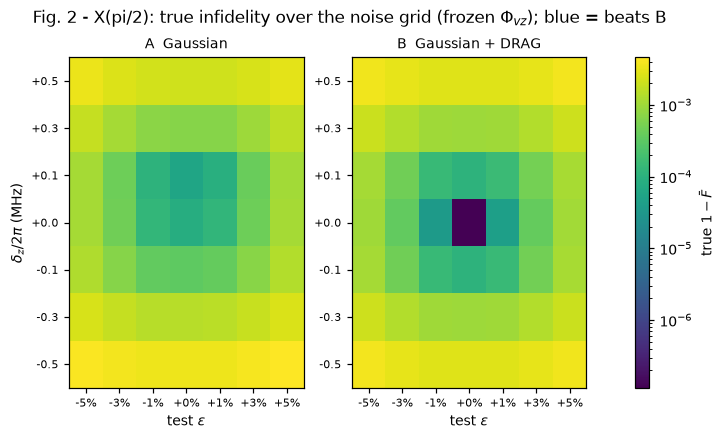

In [6]:
vmin = min(s.min() for s in sweeps.values())
vmax = max(s.max() for s in sweeps.values())
ext = [-0.5, len(al.EPS_GRID) - 0.5, -0.5, len(al.DELTA_MHZ_GRID) - 0.5]

def _noise_ticks(ax):
    ax.set_xticks(range(len(al.EPS_GRID)), [f"{e:+.0%}" for e in al.EPS_GRID], fontsize=7)
    ax.set_yticks(range(len(al.DELTA_MHZ_GRID)), [f"{d:+.1f}" for d in al.DELTA_MHZ_GRID], fontsize=7)
    ax.set_xlabel(r"test $\epsilon$")
    ax.grid(False)

RATIO_ARMS = tuple(k for k in ARM_ORDER if k not in ("A", "B"))
n_arms = len(ARM_ORDER)
nrow = 2 if RATIO_ARMS else 1
fig = plt.figure(figsize=(3.0 * n_arms + 0.8, 3.9 * nrow))
gs = fig.add_gridspec(nrow, n_arms + 1, width_ratios=[1] * n_arms + [0.06],
                      hspace=0.55, wspace=0.30)

for i, k in enumerate(ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(sweeps[k], origin="lower", aspect="auto", extent=ext,
                   norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=9)
    _noise_ticks(ax)
    if i == 0:
        ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
fig.colorbar(im, cax=fig.add_subplot(gs[0, n_arms]), label=r"true $1-\bar F$")

if RATIO_ARMS:
    ratios = {k: np.log10(sweeps[k] / sweeps["B"]) for k in RATIO_ARMS}
    lim = max(np.max(np.abs(r)) for r in ratios.values())
    for i, k in enumerate(RATIO_ARMS):
        ax = fig.add_subplot(gs[1, i + 1])
        im2 = ax.imshow(ratios[k], origin="lower", aspect="auto", extent=ext,
                        cmap="RdBu_r", vmin=-lim, vmax=lim)
        for r in range(ratios[k].shape[0]):
            for c in range(ratios[k].shape[1]):
                ax.text(c, r, f"{ratios[k][r, c]:+.1f}", ha="center", va="center", fontsize=6,
                        color="k" if abs(ratios[k][r, c]) < 0.6 * lim else "w")
        ax.set_title(rf"$\log_{{10}}[(1-\bar F)_{k} / (1-\bar F)_B]$", fontsize=9)
        _noise_ticks(ax)
        if i == 0:
            ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
    fig.colorbar(im2, cax=fig.add_subplot(gs[1, n_arms]))

fig.suptitle(f"Fig. 2 - {al.GATE.name}: true infidelity over the noise grid "
             r"(frozen $\Phi_{vz}$); blue = beats B", y=0.99)
plt.show()

for k in RATIO_ARMS:
    print(f"{k} beats B at {int((ratios[k] < 0).sum())} of {ratios[k].size} grid points.")

### Fig. 3 — the $\epsilon$ slice at $\delta_z = 0$

Solid = measured. Dashed = the budget's own prediction, i.e. $C_3$ rescaled to each
$\epsilon$ (exactly quadratic in $\epsilon$).

Arms A and B share the dashed curve: $C_3$ is a property of the design curve, and DRAG
only changes how that curve is played. The right panel is measured/predicted — how far
off the surrogate is, per arm.

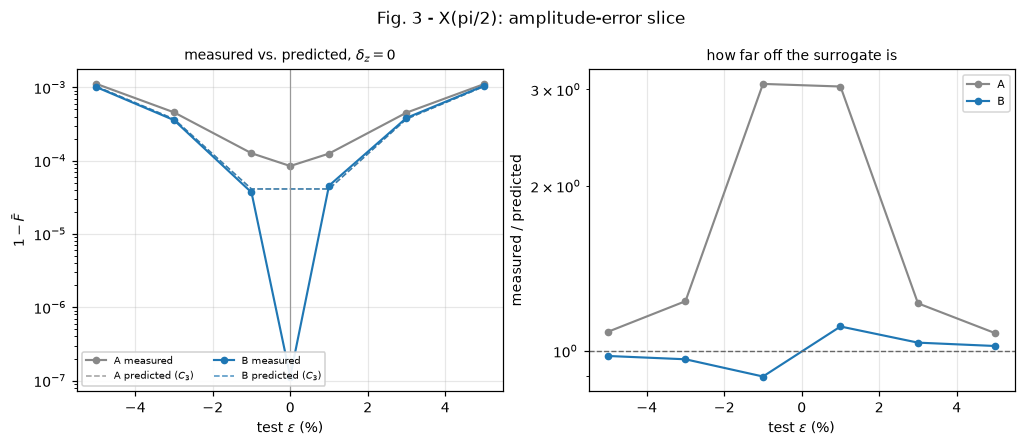

A: 1-F(+5%) = 1.1075e-03   1-F(-5%) = 1.1145e-03   asymmetry = 0.994
B: 1-F(+5%) = 1.0497e-03   1-F(-5%) = 1.0067e-03   asymmetry = 1.043


In [7]:
i0 = int(np.where(al.DELTA_MHZ_GRID == 0.0)[0][0])
fig, (ax, axr) = plt.subplots(1, 2, figsize=(11, 3.8))

nz = al.EPS_GRID != 0.0  # C3 is exactly 0 at eps = 0 and has no place on a log axis
for k in ARM_ORDER:
    ax.semilogy(al.EPS_GRID * 100, sweeps[k][i0], "o-", color=al.ARM_COLORS[k],
                lw=1.4, ms=4, label=f"{k} measured")
    pred = al.c3_prediction(arms[k])
    ax.semilogy(al.EPS_GRID[nz] * 100, pred[nz], "--", color=al.ARM_COLORS[k],
                lw=1.0, alpha=0.8, label=f"{k} predicted ($C_3$)")
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel(r"test $\epsilon$ (%)"); ax.set_ylabel(r"$1-\bar F$")
ax.set_title(r"measured vs. predicted, $\delta_z=0$", fontsize=9)
ax.legend(fontsize=6.5, ncol=2, loc="lower left", framealpha=0.9)

for k in ARM_ORDER:
    s = sweeps[k][i0]
    pred = al.c3_prediction(arms[k])
    axr.semilogy(al.EPS_GRID[nz] * 100, s[nz] / pred[nz], "o-", color=al.ARM_COLORS[k],
                 lw=1.4, ms=4, label=k)
axr.axhline(1.0, color="0.4", ls="--", lw=0.9)
axr.set_xlabel(r"test $\epsilon$ (%)"); axr.set_ylabel("measured / predicted")
axr.set_title("how far off the surrogate is", fontsize=9)
axr.legend(fontsize=7)
fig.suptitle(f"Fig. 3 - {al.GATE.name}: amplitude-error slice", y=1.02)
plt.show()

j = int(np.where(al.EPS_GRID == 0.05)[0][0])
jm = int(np.where(al.EPS_GRID == -0.05)[0][0])
for k in ARM_ORDER:
    s = sweeps[k][i0]
    print(f"{k}: 1-F(+5%) = {s[j]:.4e}   1-F(-5%) = {s[jm]:.4e}   "
          f"asymmetry = {s[j]/s[jm]:.3f}")

## Fig. 4 — surrogate vs. truth along the optimization

Each optimized arm's recorded run checkpointed every 100 iterations. The optimizer only
ever saw the surrogate; the true infidelity is recomputed here offline from each
checkpoint's coefficients, with $\Phi_{\rm vz}$ re-fitted at that iterate as a real
calibration would be.

Bottom panel: the diagnostics — fluence over $F_0$, $\max|\tau|$, peak utilisation — so
whatever correlates with a turnaround is visible right next to it.

In [8]:
TRACE_ARMS = tuple(k for k in ("C", "D", "E") if k in ARM_ORDER)
if not TRACE_ARMS:
    print("no optimized arm has a recorded run yet - Fig. 4 needs at least one.")
else:
    traces = {k: al.checkpoint_trace(k) for k in TRACE_ARMS}

    fig, (ax, axd) = plt.subplots(2, 1, figsize=(9.5, 6.8), sharex=True,
                                  gridspec_kw={"height_ratios": [1.5, 1.0], "hspace": 0.12})
    for k in TRACE_ARMS:
        tr, col = traces[k], al.ARM_COLORS[k]
        ax.semilogy(tr["iter"], tr["surrogate_total"], "--", lw=1.3, color=col, alpha=0.75,
                    label=rf"{k} surrogate $\sum_i w_i C_i$")
        ax.semilogy(tr["iter"], tr["true_infidelity"], "-o", lw=1.7, ms=3.0, color=col,
                    label=rf"{k} true $1-\bar F$ (three-level, offline)")
        kmin = int(np.argmin(tr["true_infidelity"]))
        ax.plot(tr["iter"][kmin], tr["true_infidelity"][kmin], "*", ms=12, color=col, zorder=5)
    ax.axhline(rows["B"]["baseline_infidelity"], ls="--", lw=1.0, color="0.35")
    ax.text(0.01, rows["B"]["baseline_infidelity"], " arm B baseline",
            transform=ax.get_yaxis_transform(), va="bottom", ha="left", fontsize=7, color="0.35")
    ax.set_ylabel(r"$1-\bar F$")
    ax.set_title(f"Fig. 4 - {al.GATE.name}: surrogate vs. truth along the optimization "
                 "(star = each arm's true minimum)", fontsize=10)
    ax.legend(fontsize=7, loc="lower left", ncol=2)

    for k in TRACE_ARMS:
        tr, col = traces[k], al.ARM_COLORS[k]
        axd.plot(tr["iter"], tr["fluence_over_floor"], "-", lw=1.5, color=col,
                 label=rf"{k} $\int\kappa^2dt / F_0$")
        axd.plot(tr["iter"], tr["max_abs_tau"] * 10, ":", lw=1.3, color=col,
                 label=rf"{k} $\max|\tau|\times10$")
        axd.plot(tr["iter"], tr["peak_frac"], "-.", lw=1.1, color=col, alpha=0.7,
                 label=rf"{k} peak/$\Omega_{{\max}}$")
    axd.set_xlabel("iteration"); axd.set_ylabel("diagnostic")
    axd.legend(fontsize=6.5, ncol=3, loc="upper left")
    plt.show()

    for k in TRACE_ARMS:
        tr = traces[k]
        kmin = int(np.argmin(tr["true_infidelity"]))
        print(f"{k}: true minimum {tr['true_infidelity'][kmin]:.4e} at iter "
              f"{int(tr['iter'][kmin])} of {int(tr['iter'][-1])}; final "
              f"{tr['true_infidelity'][-1]:.4e}; final fluence "
              f"{tr['fluence_over_floor'][-1]:.2f} F0")

no optimized arm has a recorded run yet - Fig. 4 needs at least one.


## 6. Export

120-point CSVs (`time_ns, Omega_x_rad_per_ns, Omega_y_rad_per_ns`, the F07 schema),
coefficient JSONs for exact regeneration, and a manifest. The sampling loss is the
120-point infidelity over the fine-grid one — reported, not thresholded.

In [9]:
manifest = al.export_arms(arms, rows)
print(json.dumps(manifest["arms"], indent=1))
print("\nfiles:")
for p in sorted((Path.cwd() / "waveforms").iterdir()):
    print(f"  {p.relative_to(Path.cwd())}  ({p.stat().st_size} bytes)")

{
 "A": {
  "name": "Gaussian",
  "layer": "planar",
  "csv": "waveforms/A_gaussian_120pt.csv",
  "json": "waveforms/A_gaussian.json",
  "run_id": null,
  "infidelity_120pt": 8.454040022110032e-05,
  "infidelity_fine": 8.454081754483145e-05,
  "sampling_loss_ratio": 0.999995063642117
 },
 "B": {
  "name": "Gaussian + DRAG",
  "layer": "planar_drag",
  "csv": "waveforms/B_gaussian_drag_120pt.csv",
  "json": "waveforms/B_gaussian_drag.json",
  "run_id": null,
  "infidelity_120pt": 1.1361220642047698e-07,
  "infidelity_fine": 1.1370134611610183e-07,
  "sampling_loss_ratio": 0.9992160189947634
 }
}

files:
  waveforms/.gitkeep  (0 bytes)
  waveforms/A_gaussian.json  (1064 bytes)
  waveforms/A_gaussian_120pt.csv  (7007 bytes)
  waveforms/B_gaussian_drag.json  (1101 bytes)
  waveforms/B_gaussian_drag_120pt.csv  (7063 bytes)


## 7. What the run says

Fill in from the numbers above, not in advance:

* Table 1 — which arm wins on the predicted budget, which on the truth, and the
  `true/pred` ratio per arm. Compare against the $X(\pi)$ folder's Table 1.
* Fig. 1 — peak utilisation. If the optimized arms sit far below $\Omega_{\max}$, the peak
  bound was never the guard that mattered and the fluence cap is doing all the work.
* Fig. 2/3 — whether the surrogate/truth gap shrinks with $\theta$ (it should, if the gap
  is driven by the waived $\delta\tau\sim\epsilon\kappa^2/\Delta$ term, which scales with
  $\kappa^2$) or does not (which would point somewhere else).
* Fig. 4 — where the truth turns around, and which diagnostic moves with it.

★ Open question deliberately left open: $T=50$ ns is kept for comparability with the
$X(\pi)$ study, but a $\pi/2$ gate has no physical reason to take as long as a $\pi$ gate.
Since the decoherence floor is $\propto T$ and the coherent terms are not, the $T$ that
minimises total error is a different question — one worth its own run, not a footnote here.